In [319]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from matplotlib import pyplot as plt
import seaborn as sns
import time
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from torch.utils.data.dataloader import DataLoader
from torch.utils.data.dataset import TensorDataset

plt.style.use("default")

In [320]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [321]:
mnist = fetch_openml('mnist_784', version=1, as_frame=False) # X: (70000, 784)

In [322]:
X, y = mnist["data"], mnist["target"]
X = torch.Tensor(X.astype(np.float32) / 255.0).reshape(-1, 1, 28, 28)
y = torch.Tensor(y.astype(np.int64))
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=10000, random_state=42, stratify=y
)
X_test = X_test.to(device)

In [323]:
X_trainval.shape

torch.Size([60000, 1, 28, 28])

In [324]:
train_dataset = TensorDataset(X_trainval.to(device), y_trainval.to(device))
test_dataset = TensorDataset(X_test.to(device), y_test.to(device))

test_loader = DataLoader(test_dataset, batch_size=1000)

In [325]:
class MLP(nn.Module):
    def __init__(self):
        super(MLP, self).__init__()

        # Thanx to https://medium.com/data-science-collective/implementing-cnn-in-pytorch-testing-on-mnist-99-26-test-accuracy-5c63876c6ac8
        self.model = nn.Sequential(
            nn.ZeroPad2d(2),
            nn.Conv2d(1, 16, 5, 1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Flatten(),
            nn.LazyLinear(out_features=10),
        )

        self.train_loss_per_epoch = None
        self.val_loss_per_batch = None
        self.best_val_loss = None

    def forward(self, x):
        x = self.model(x)
        return x


In [326]:
def train_one_model(max_epochs: int, batch_size: int, lr: float) -> MLP:
    model = MLP()
    model.to(device)
    model.train()

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    loss_fn = nn.CrossEntropyLoss()

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    n_reports = 10
    print_every = max(max_epochs // n_reports, 1)

    train_loss_per_epoch = np.zeros(max_epochs)
    val_loss_per_batch = np.zeros(max_epochs)

    for epoch in range(max_epochs):
        for data, target in train_loader:
            optimizer.zero_grad()

            y_pred = model(data)

            loss = loss_fn(y_pred, target.long())
            loss.backward()

            optimizer.step()

        model.eval()

        with torch.no_grad():
            loss = 0.0

            for data, target in train_loader:
                y_pred = model(data)
                loss += loss_fn(y_pred, target.long()).item()

            loss_avg = loss / len(train_loader)
            train_loss_per_epoch[epoch] = loss_avg

            loss = 0.0

            for data, target in test_loader:
                y_pred = model(data)
                loss += loss_fn(y_pred, target.long()).item()

            loss_avg = loss / len(test_loader)
            val_loss_per_batch[epoch] = loss_avg

            # if epoch % print_every == 0:
            #     print(f"{epoch=}\tCrossEntropy = {loss_avg:.3f}")

        model.train()

    model.train_loss_per_epoch = train_loss_per_epoch
    model.val_loss_per_batch = val_loss_per_batch
    model.best_val_loss = np.min(val_loss_per_batch).item()

    model.eval()
    return model

In [327]:
batch_sizes = [
    4096,
    2048,
    1024,
    512,
    256,
    128,
    64,
    32,
    16,
    8,
]

learning_rates = [
    0.00001,
    0.0001,
    0.001,
    0.01,
    0.1,
]

RUNS = 2
losses = np.zeros((RUNS, len(batch_sizes), len(learning_rates)), dtype=float)
training_durations = np.zeros_like(losses, dtype=float)

for run in range(RUNS):
    for i, batch_size in enumerate(batch_sizes):
        for j, lr in enumerate(learning_rates):
            lr = 0.1

            start = time.time()
            model = train_one_model(5, batch_size, lr)
            duration = time.time() - start

            losses[run, i, j] = model.best_val_loss
            training_durations[run, i, j] = duration

            perc_done = 100*(i*models.shape[1] + j + 1)//models.size
            print(f"[{perc_done:3n}%] model ({i}, {j}) trained with best val loss = {model.best_val_loss}")

    print(f"Run {run+1}/{RUNS} done\n")

/home/dom/python_global_venvs/ML/venv/lib64/python3.11/site-packages/torch/nn/modules/lazy.py:181: UserWarning: Lazy modules are a new feature under heavy development so changes to the API or functionality can happen at any moment.
  warnings.warn('Lazy modules are a new feature under heavy development '


[  2%] model (0, 0) trained with best val loss = 0.9549388647079468
[  4%] model (0, 1) trained with best val loss = 0.29574117064476013
[  6%] model (0, 2) trained with best val loss = 2.1675042390823362
[  8%] model (0, 3) trained with best val loss = 1.0309936940670013
[ 10%] model (0, 4) trained with best val loss = 1.686880648136139
[ 12%] model (1, 0) trained with best val loss = 0.16414379924535752
[ 14%] model (1, 1) trained with best val loss = 0.22462504953145981
[ 16%] model (1, 2) trained with best val loss = 0.34450852274894717
[ 18%] model (1, 3) trained with best val loss = 0.3171488970518112
[ 20%] model (1, 4) trained with best val loss = 0.2609396383166313
[ 22%] model (2, 0) trained with best val loss = 0.15783041715621948
[ 24%] model (2, 1) trained with best val loss = 0.1534304827451706
[ 26%] model (2, 2) trained with best val loss = 0.23143784701824188
[ 28%] model (2, 3) trained with best val loss = 0.316122379899025
[ 30%] model (2, 4) trained with best val lo

In [328]:
losses.reshape(-1, 5)

array([[0.95493886, 0.29574117, 2.16750424, 1.03099369, 1.68688065],
       [0.1641438 , 0.22462505, 0.34450852, 0.3171489 , 0.26093964],
       [0.15783042, 0.15343048, 0.23143785, 0.31612238, 0.30917587],
       [0.24392633, 0.26415886, 0.26559454, 0.27189584, 0.2702501 ],
       [0.14833097, 0.20721116, 0.14125841, 0.1400589 , 0.12717711],
       [2.30594516, 0.13676842, 0.27807603, 0.24950191, 0.15971549],
       [0.15454074, 0.285067  , 0.18707904, 0.28195545, 0.19156367],
       [0.3417452 , 2.30608797, 2.31010554, 2.31102846, 0.31700437],
       [2.31326611, 0.37190289, 0.39440802, 0.41941434, 0.41475511],
       [2.32202754, 2.32006917, 2.30847247, 2.31714714, 2.3132185 ],
       [2.30116944, 1.15521153, 0.28167862, 0.88826144, 0.40235466],
       [0.29450218, 0.49051183, 0.31640365, 0.40914123, 0.32595323],
       [0.33313151, 0.38502254, 0.31404865, 0.15258477, 0.28530681],
       [0.24770557, 2.30255315, 0.14458177, 0.09498488, 0.34686739],
       [0.11172267, 0.25678647, 0.

In [329]:
# Appends the results to the CSV
try:
    df = pd.read_csv("batch_size_losses.csv", header=None)
    df = pd.concat([df, pd.DataFrame(losses.reshape(-1, 5))], axis=0)
except FileNotFoundError:
    df = pd.DataFrame(losses)

df.to_csv("batch_size_losses.csv", index=False, header=False)
df

,0,1,2,3,4
0,0.374597,2.301324,0.956208,2.265458,2.301165
1,0.247205,0.387024,2.301224,0.347141,0.464161
2,0.189536,0.293295,2.301641,0.150651,0.323434
3,0.321447,0.275515,0.266691,0.148513,0.286127
4,2.303589,0.153664,0.303408,0.266169,0.136136
5,0.183306,2.304226,0.288853,0.171408,0.272167
6,0.245347,2.303319,2.308307,0.254138,0.305786
7,0.240276,0.266433,2.306788,0.340075,0.332162
8,0.407177,0.461700,2.307509,2.308471,2.306384
9,2.318307,2.316847,2.318332,0.649225,2.309580


In [330]:
# Averaging
losses_combined = np.stack([df[i:i+10] for i in range(0, len(df), 10)])
losses = losses_combined.mean(axis=0)
losses_combined.shape

(5, 10, 5)

<Axes: >

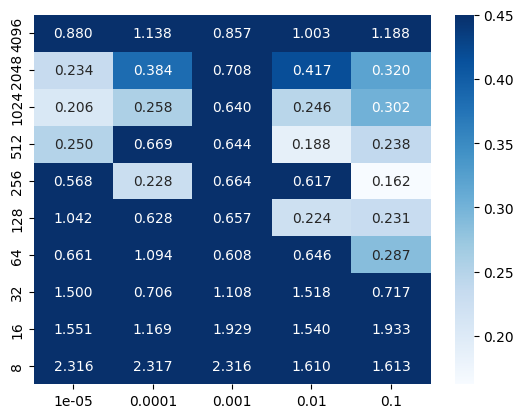

In [331]:
sns.heatmap(losses, annot=True, vmax=0.45, fmt=".3f", xticklabels=learning_rates, yticklabels=batch_sizes, cmap="Blues")

<Axes: >

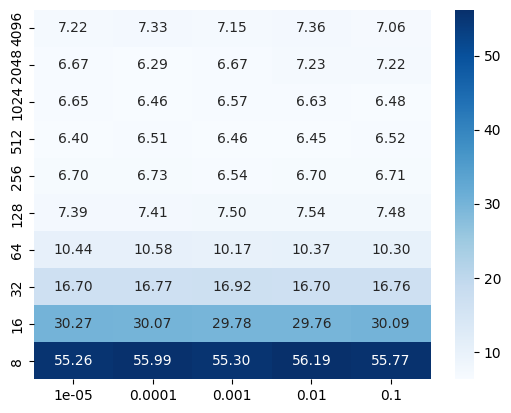

In [332]:
training_durations = training_durations.mean(axis=0)
sns.heatmap(training_durations, annot=True, fmt=".2f", xticklabels=learning_rates, yticklabels=batch_sizes, cmap="Blues")

In [333]:
inv_training_eff = losses*training_durations

inv_training_eff

array([[  6.35449468,   8.34476166,   6.12768945,   7.38382398,
          8.38114253],
       [  1.56281451,   2.41379452,   4.7191833 ,   3.01467532,
          2.31132164],
       [  1.36902351,   1.66483022,   4.20606421,   1.63406303,
          1.95619473],
       [  1.60013953,   4.35960003,   4.16395205,   1.21183584,
          1.5538842 ],
       [  3.80938476,   1.53265628,   4.33908003,   4.13206461,
          1.08993907],
       [  7.7035344 ,   4.65506704,   4.92872334,   1.68807386,
          1.73177641],
       [  6.9025774 ,  11.57595033,   6.18370254,   6.69807406,
          2.95681153],
       [ 25.0557893 ,  11.8469407 ,  18.74959326,  25.3551592 ,
         12.01542564],
       [ 46.93861265,  35.13353277,  57.42304572,  45.84200492,
         58.15233295],
       [127.97236013, 129.72276782, 128.07482748,  90.49213453,
         89.953775  ]])

<Axes: >

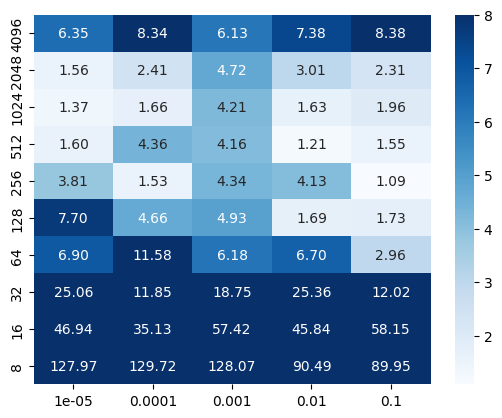

In [334]:
sns.heatmap(inv_training_eff, annot=True, vmax=8, fmt=".2f", xticklabels=learning_rates, yticklabels=batch_sizes, cmap="Blues")

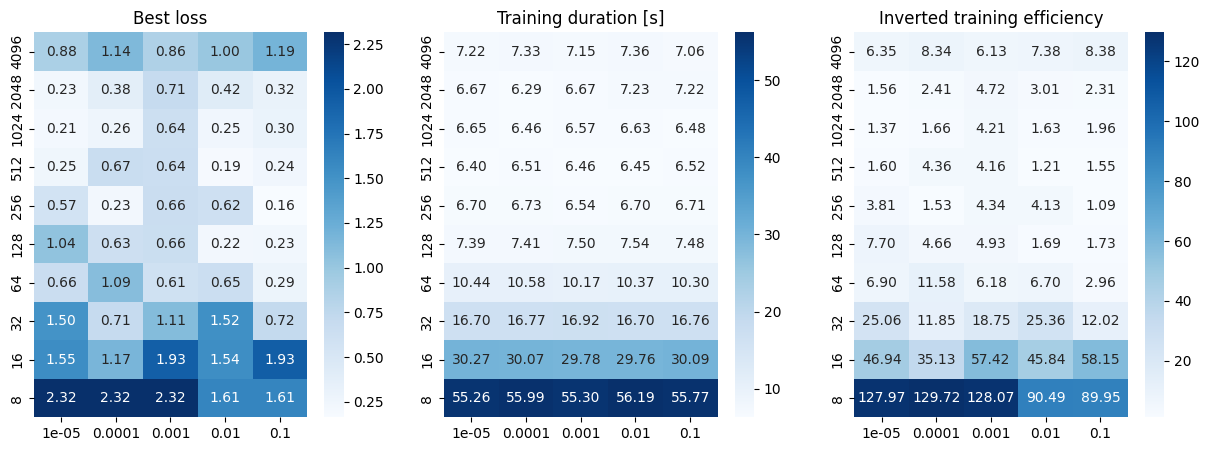

In [335]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

titles = ["Best loss", "Training duration [s]", "Inverted training efficiency"]
for ax, arr, title in zip(axs, [losses, training_durations, inv_training_eff], titles):
    sns.heatmap(arr, annot=True, fmt=".2f", xticklabels=learning_rates, yticklabels=batch_sizes, cmap="Blues", ax=ax)
    ax.set_title(title)

plt.show()
